In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2

In [10]:
# =========================
# INPUT: your data
# =========================
# X should be shape (N, 72)
# Example:
# X = np.random.randn(1000, 72)

train_data = np.load("data_processed/train_data_scaled.npz")
# val_data_s = np.load("data_processed/val_data_scaled.npz")
# test_data_s = np.load("data_processed/test_data_scaled.npz")

X_train = train_data["x"]
N, d = X_train.shape
# y_train_s = train_data_s["age"]

# X_val_s = val_data_s["x"]
# y_val_s = val_data_s["age"]

# X_test_s = test_data_s["x"]
# y_test_s = test_data_s["age"]

In [8]:
# -------------------------
# 2. Isolation Forest
# -------------------------
iso = IsolationForest(contamination=0.05, random_state=0)
labels = iso.fit_predict(X_train)

# -1 = outlier, +1 = normal
outliers_iso = np.where(labels == -1)[0]
print(f"[IsolationForest] Outliers detected: {len(outliers_iso)} ({len(outliers_iso)/N:.2%})")

[IsolationForest] Outliers detected: 638 (5.01%)


In [11]:
# -------------------------
# 3. Mahalanobis distance
# -------------------------
mean = np.mean(X_train, axis=0)
cov = np.cov(X_train, rowvar=False)
cov_inv = np.linalg.pinv(cov)

mahal_dist = np.array([
    mahalanobis(x, mean, cov_inv) for x in X_train
])

# Threshold using chi-square distribution
threshold = np.sqrt(chi2.ppf(0.99, df=d))  # 99% confidence
outliers_mahal = np.where(mahal_dist > threshold)[0]

print(f"[Mahalanobis] Outliers detected: {len(outliers_mahal)} ({len(outliers_mahal)/N:.2%})")

[Mahalanobis] Outliers detected: 1050 (8.24%)


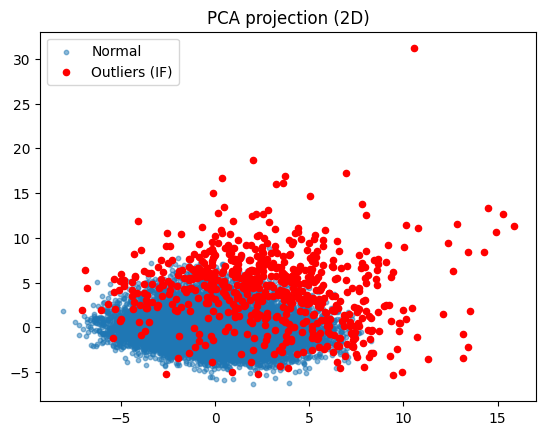

In [12]:
# -------------------------
# 4. PCA visualization (2D)
# -------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10, alpha=0.5, label="Normal")

# Highlight Isolation Forest outliers
plt.scatter(X_pca[outliers_iso, 0],
            X_pca[outliers_iso, 1],
            color='red', s=20, label="Outliers (IF)")

plt.title("PCA projection (2D)")
plt.legend()
plt.show()

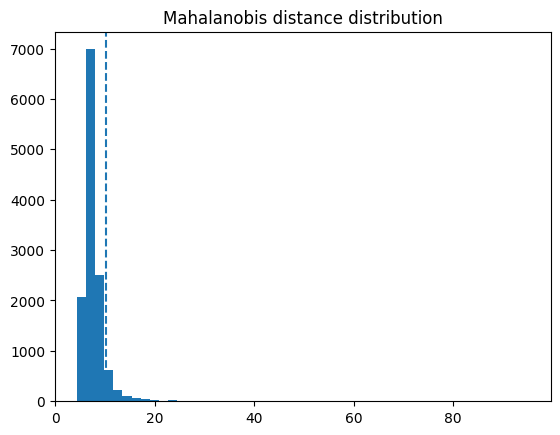

In [13]:
# -------------------------
# 5. Distance distribution
# -------------------------

plt.figure()
plt.hist(mahal_dist, bins=50)
plt.axvline(threshold, linestyle='--')
plt.title("Mahalanobis distance distribution")
plt.show()

In [15]:
# -------------------------
# 6. Simple noise indicator
# -------------------------
# Measure average variance per feature
feature_variances = np.var(X_train, axis=0)
print(f"Mean feature variance: {feature_variances.mean():.3f}")

# High variance spread across features may indicate noise

# -------------------------
# 7. Final summary
# -------------------------
print("\n=== SUMMARY ===")
print(f"IsolationForest outliers: {len(outliers_iso)}")
print(f"Mahalanobis outliers: {len(outliers_mahal)}")

if len(outliers_iso) > 0.02 * N or len(outliers_mahal) > 0.02 * N:
    print("Dataset likely contains OUTLIERS → consider SmoothL1Loss")
else:
    print("No strong outliers detected → MSELoss is likely fine")

Mean feature variance: 1.000

=== SUMMARY ===
IsolationForest outliers: 638
Mahalanobis outliers: 1050
Dataset likely contains OUTLIERS → consider SmoothL1Loss
